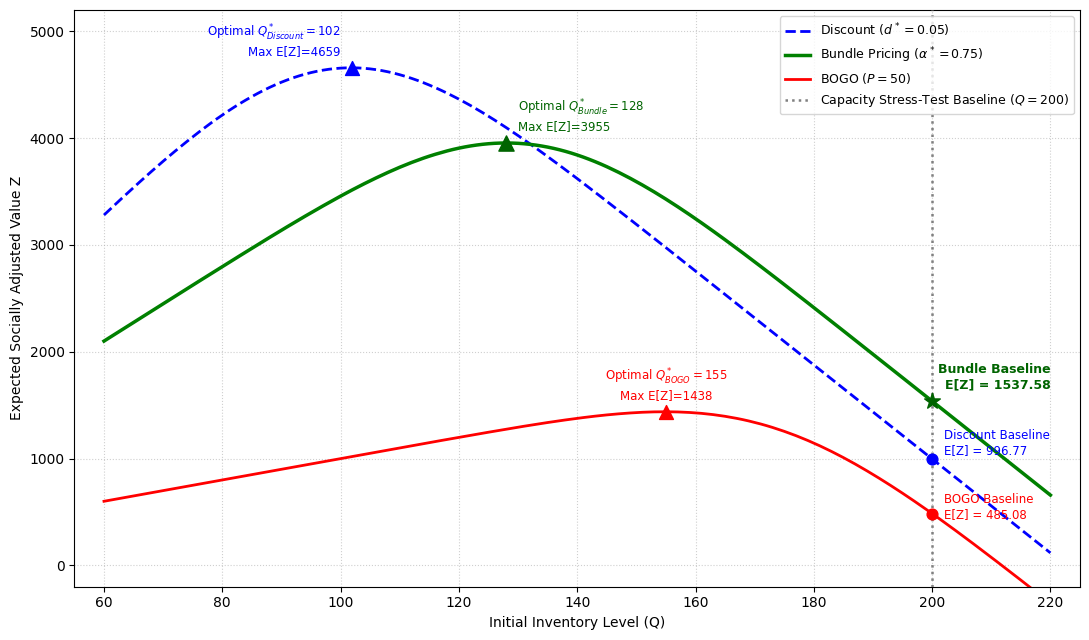

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


a, b, t, P, C, Cw, lmbda = 200, 1.0, 3, 100, 40, 2, 2
sigma = 20
delta_val = 2.0

P_discount, P_bundle, P_bogo = 95, 75, 50
theta_discount, theta_bundle, theta_bogo = 0.00, 0.10, 0.20

np.random.seed(42)
epsilon = np.random.normal(0, sigma, 10000)

D_disc = np.maximum(
    (1 + theta_discount) * (a - b * P_discount - delta_val * t) + epsilon, 0
)
D_bund = np.maximum(
    (1 + theta_bundle) * (a - b * P_bundle - delta_val * t) + epsilon, 0
)
D_bogo = np.maximum(
    (1 + theta_bogo) * (a - b * P_bogo - delta_val * t) + epsilon, 0
)


Q_range = np.linspace(60, 220, 161)
plot_data = {'Q': [], 'Discount': [], 'Bundle': [], 'BOGO': []}

for Q_val in Q_range:
  Y_disc = np.minimum(Q_val, D_disc)
  Y_bund = np.minimum(Q_val, D_bund)
  Y_bogo = np.minimum(Q_val, D_bogo)

  Z_disc = P_discount * Y_disc - C * Q_val - (Cw + lmbda) * (Q_val - Y_disc)
  Z_bund = P_bundle * Y_bund - C * Q_val - (Cw + lmbda) * (Q_val - Y_bund)
  Z_bogo = P_bogo * Y_bogo - C * Q_val - (Cw + lmbda) * (Q_val - Y_bogo)

  plot_data['Q'].append(Q_val)
  plot_data['Discount'].append(np.mean(Z_disc))
  plot_data['Bundle'].append(np.mean(Z_bund))
  plot_data['BOGO'].append(np.mean(Z_bogo))

df_plot = pd.DataFrame(plot_data)


idx_peak_disc = df_plot['Discount'].idxmax()
idx_peak_bund = df_plot['Bundle'].idxmax()
idx_peak_bogo = df_plot['BOGO'].idxmax()


plt.figure(figsize=(11, 6.5))

plt.plot(
    df_plot['Q'],
    df_plot['Discount'],
    label=r'Discount ($d^*=0.05$)',
    color='blue',
    linestyle='--',
    linewidth=2,
)
plt.plot(
    df_plot['Q'],
    df_plot['Bundle'],
    label=r'Bundle Pricing ($\alpha^*=0.75$)',
    color='green',
    linewidth=2.5,
)
plt.plot(
    df_plot['Q'],
    df_plot['BOGO'],
    label=r'BOGO ($P=50$)',
    color='red',
    linewidth=2,
)


q_p_disc = df_plot.loc[idx_peak_disc, 'Q']
z_p_disc = df_plot.loc[idx_peak_disc, 'Discount']
plt.scatter([q_p_disc], [z_p_disc], color='blue', s=100, marker='^', zorder=8)
plt.text(
    q_p_disc - 2,
    z_p_disc + 120,
    f'Optimal $Q^*_{{Discount}}={q_p_disc:.0f}$\nMax E[Z]={z_p_disc:.0f}',
    fontsize=8.5,
    color='blue',
    ha='right',
)


q_p_bund = df_plot.loc[idx_peak_bund, 'Q']
z_p_bund = df_plot.loc[idx_peak_bund, 'Bundle']
plt.scatter(
    [q_p_bund], [z_p_bund], color='darkgreen', s=120, marker='^', zorder=8
)
plt.text(
    q_p_bund + 2,
    z_p_bund + 120,
    f'Optimal $Q^*_{{Bundle}}={q_p_bund:.0f}$\nMax E[Z]={z_p_bund:.0f}',
    fontsize=8.5,
    color='darkgreen',
    ha='left',
)


q_p_bogo = df_plot.loc[idx_peak_bogo, 'Q']
z_p_bogo = df_plot.loc[idx_peak_bogo, 'BOGO']
plt.scatter([q_p_bogo], [z_p_bogo], color='red', s=100, marker='^', zorder=8)
plt.text(
    q_p_bogo,
    z_p_bogo + 120,
    f'Optimal $Q^*_{{BOGO}}={q_p_bogo:.0f}$\nMax E[Z]={z_p_bogo:.0f}',
    fontsize=8.5,
    color='red',
    ha='center',
)


idx_base = (df_plot['Q'] - 200).abs().idxmin()
v_disc = df_plot.loc[idx_base, 'Discount']
v_bund = df_plot.loc[idx_base, 'Bundle']
v_bogo = df_plot.loc[idx_base, 'BOGO']

plt.axvline(
    x=200,
    color='gray',
    linestyle=':',
    linewidth=1.8,
    zorder=3,
    label='Capacity Stress-Test Baseline ($Q=200$)',
)

plt.scatter([200], [v_bund], color='darkgreen', s=140, marker='*', zorder=10)
plt.text(
    220,
    v_bund + 120,
    f'Bundle Baseline\nE[Z] = {v_bund:.2f}',
    fontsize=9,
    fontweight='bold',
    color='darkgreen',
    ha='right',
)

plt.scatter([200], [v_disc], color='blue', s=60, zorder=10)
plt.text(
    202,
    v_disc + 50,
    f'Discount Baseline\nE[Z] = {v_disc:.2f}',
    fontsize=8.5,
    color='blue',
    ha='left',
)

plt.scatter([200], [v_bogo], color='red', s=60, zorder=10)
plt.text(
    202,
    v_bogo - 40,
    f'BOGO Baseline\nE[Z] = {v_bogo:.2f}',
    fontsize=8.5,
    color='red',
    ha='left',
)


plt.xlabel('Initial Inventory Level (Q)', fontsize=10)
plt.ylabel('Expected Socially Adjusted Value Z', fontsize=10)
plt.xlim(55, 225)
plt.ylim(-200, 5200)
plt.legend(loc='upper right', fontsize=9)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()